# **ENVIROMENT**

In [1]:
!pip -q install transformers emoji --upgrade
!pip -q install nlpaug==1.1.10 || echo "nlpaug optional only"
!pip -q install --upgrade transformers huggingface-hub


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 75.6 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 81.5 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.1.1 requires pyarrow>=21.0.0, but you have pyarrow 19.0.1 which is incompatible.
gradio 5.38.1 requires pydantic<2.12,>=2.0, but you have pydantic 2.12.0a1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.8/410.8 kB 9.0 MB/s eta 0:00:00:00:01


In [2]:
import os, random, json, gc, re, emoji, numpy as np, pandas as pd, tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score
from transformers import TFAutoModel, AutoTokenizer, logging as hf_logging
import matplotlib.pyplot as plt

hf_logging.set_verbosity_error()


2025-11-26 19:37:50.407859: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764185870.593693      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764185870.646287      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
import os
from huggingface_hub import login

# Jika model private -> export token di environment (atau login interactive)
# os.environ["HF_TOKEN"] = "hf_xxx..."   # <- jika Anda punya token, aktifkan baris ini (jangan commit token ke repo)
if "HF_TOKEN" in os.environ:
    login(token=os.environ["HF_TOKEN"])


In [4]:
# ---- Seed (reproducibility) ----
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ Environment ready with fixed random seeds (42).")


✅ Environment ready with fixed random seeds (42).


In [5]:
# ---- Folder structure ----
for d in ["models", "ckpt", "results"]:
    os.makedirs(d, exist_ok=True)
print("📁 Folder structure prepared → models/, ckpt/, results/")

📁 Folder structure prepared → models/, ckpt/, results/


In [6]:

# ---- Global toggles ----
MAX_LEN = 128
use_augment   = True       # aktifkan augmentasi untuk dataset kecil (<2000 data)
augment_ratio = 2         # 1 augment per data train (aman & stabil)
ENABLE_ROC_PR = True       # untuk binary auto plot ROC nanti
SAVE_PROBA_IN_CSV = True
import math
import traceback


print(f"🧩 Config → use_augment={use_augment}, augment_ratio={augment_ratio}, MAX_LEN={MAX_LEN}")



🧩 Config → use_augment=True, augment_ratio=2, MAX_LEN=128


In [7]:
# Konfigurasi TensorFlow agar efisien di GPU Kaggle
import tensorflow as tf
tf.config.optimizer.set_jit(True)  # aktifkan XLA compiler
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print("⚙️ TensorFlow optimized with XLA + Mixed Precision.")

⚙️ TensorFlow optimized with XLA + Mixed Precision.


# **LOAD DATA & PREPROCESSING**


In [8]:
# ==========================================================
# 1️⃣ LOAD DATASET OTOMATIS (Multi-Path Compatible)
# ==========================================================
CANDIDATE_PATHS = [
    "/kaggle/input/dataset-facialwash/dataset (3).csv",
    "/mnt/data/dataset (3).csv",
    "dataset (3).csv"
]

data_path = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if not data_path:
    raise FileNotFoundError("❌ Tidak menemukan file dataset (3).csv. Pastikan path benar.")

print(f"📦 Dataset ditemukan di: {data_path}")
df = pd.read_csv(data_path).drop_duplicates().reset_index(drop=True)
print(f"📊 Jumlah data awal: {len(df)}")

# ==========================================================
# 2️⃣ TEXT CLEANING & NORMALIZATION (VERSI FINAL)
# ==========================================================
def clean_text(text: str) -> str:
    """
    Buang karakter aneh, tapi pertahankan:
    - huruf/angka (\w)
    - spasi (\s)
    - tanda baca penting: . , ! ? @ #
    """
    return re.sub(r'[^\w\s.,!?@#]+', '', text)

def preprocess_text(text):
    # pastikan string
    text = str(text)

    # ubah emoji → teks, lalu lower (aman untuk IndoBERT uncased)
    text = emoji.demojize(text)
    text = text.lower()

    # ganti URL → token khusus
    text = re.sub(r'https?://\S+', 'HTTPURL', text)

    # buang tanda '#' tapi simpan kata hashtag
    # contoh: "#jerawatanparah" → "jerawatanparah"
    text = re.sub(r'#(\w+)', r'\1', text)

    # ganti mention → @USER
    text = re.sub(r'@\S+', '@USER', text)

    # cleaning karakter non-alfanumerik berlebih, tapi tetap jaga . , ! ? @ #
    text = clean_text(text)

    # rapikan spasi ganda
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Validasi kolom
assert "Review Produk" in df.columns and "Label" in df.columns, "Kolom wajib: Review Produk, Label"

# Terapkan preprocessing
df["processed_text"] = df["Review Produk"].apply(preprocess_text)

# ==========================================================
# 3️⃣ LABEL ENCODING (String → Int)
# ==========================================================
label_dict = {label: i for i, label in enumerate(sorted(df["Label"].unique()))}
inv_label = {v: k for k, v in label_dict.items()}
df["Label"] = df["Label"].map(label_dict).astype(int)
class_names = [inv_label[i] for i in range(len(inv_label))]

print("🎯 Label mapping:")
for k, v in label_dict.items():
    print(f"  - {k} → {v}")


📦 Dataset ditemukan di: /kaggle/input/dataset-facialwash/dataset (3).csv
📊 Jumlah data awal: 500
🎯 Label mapping:
  - Negative → 0
  - Positive → 1


In [9]:
df[["Review Produk", "processed_text"]].head(10)


,Review Produk,processed_text
0,Aku suka banget sama ini. Cuma ini cleanser ya...,aku suka banget sama ini. cuma ini cleanser ya...
1,Walaupun produknya mengklaim dapat digunakan s...,walaupun produknya mengklaim dapat digunakan s...
2,Thanks God for this product. Produk ini udah p...,thanks god for this product. produk ini udah p...
3,Another favorite product from Cetaphil. Seneng...,another favorite product from cetaphil. seneng...
4,awalnya kaget karena cleanser ini enggak berbu...,awalnya kaget karena cleanser ini enggak berbu...
5,So far aku cocok sama cetaphil ini. Dan sudah ...,so far aku cocok sama cetaphil ini. dan sudah ...
6,My HG cleanser! Dengan kulit yg oily tapi keri...,my hg cleanser! dengan kulit yg oily tapi keri...
7,Sampai sekarang tetap setia menggunakan Cethap...,sampai sekarang tetap setia menggunakan cethap...
8,Really really love this cleanser. Kulit wajahk...,really really love this cleanser. kulit wajahk...
9,"Cetaphil bikin kulit aku sehat kembali, tadiny...","cetaphil bikin kulit aku sehat kembali, tadiny..."


In [10]:
# ==========================================================
# 4️⃣ SPLIT DATA 70 / 10 / 20 (STRATIFIED)
# ==========================================================
X = df["processed_text"]
y = df["Label"]

# Tahap 1: train 70%, temp 30%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)

# Tahap 2: split temp menjadi val 10% dan test 20%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, stratify=y_temp, random_state=SEED
)

print(f"📊 Data split selesai:")
print(f"   🔹 Train = {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"   🔹 Val   = {len(X_val)} ({len(X_val)/len(df)*100:.1f}%)")
print(f"   🔹 Test  = {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")

# ----------------------------------------------------------
# 🔁 RESET INDEX AGAR URUTAN RAPI & SIMPAN META TEST
# ----------------------------------------------------------
# Simpan index asli test set (merujuk ke df awal)
test_index = X_test.index

# Reset index X/y (supaya kompatibel dengan Keras / numpy)
X_train = X_train.reset_index(drop=True)
X_val   = X_val.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_val   = y_val.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

# Buat dataframe metadata untuk test set
# (ID Data, Nama Produk, Jenis Kulit, Rating, Review asli)
df_test_meta = (
    df.loc[test_index, ["ID Data", "Nama Produk", "Jenis Kulit", "Rating", "Review Produk"]]
      .reset_index(drop=True)
)

print("\n✅ df_test_meta siap dipakai untuk analisis per produk/jenis kulit/rating.")
display(df_test_meta.head())


📊 Data split selesai:
   🔹 Train = 350 (70.0%)
   🔹 Val   = 50 (10.0%)
   🔹 Test  = 100 (20.0%)

✅ df_test_meta siap dipakai untuk analisis per produk/jenis kulit/rating.


,ID Data,Nama Produk,Jenis Kulit,Rating,Review Produk
0,A134,Hadalabo: Tamagohada Mild Peeling Face Wash,Combination,1,i wish i could love this...but :( padahal dike...
1,A034,Cetaphil: Gentle Skin Cleanser,Oily,1,waktu itu beli cetaphil yg gentle skin cleanse...
2,A254,Ponds: Acne Solution AntiAcne Facial Foam,Dry,5,pake pas ada bakal jerawat dan ampuh buat 'men...
3,A156,Cosrx: Low pH Good Morning Gel Cleanser,Dry,5,my holy graill !!! clenser yg selalu aku pakai...
4,A419,Wardah: Lightening Gentle Wash,Combination,1,saya pakai wardah lightening gentlewash dan ra...


# **SPLIT 70/10/20**

# **AUGMENTATION (Hybrid: Custom EDA 🇮🇩 + nlpaug opsional)**

In [11]:
# ==========================================================
# 3️⃣ AUGMENTATION (Hybrid: Custom EDA 🇮🇩 + nlpaug opsional)
# ==========================================================
import os, random, re
from collections import Counter

# Pastikan augment_ratio sudah diset di global config
# augment_ratio = 1  (recommended)

# -- Kamus stopwords & sinonim (tetap seperti milikmu) --
ID_STOPWORDS = {
    "yang","dan","di","ke","dari","untuk","dengan","pada","atau","juga","tidak","nggak","ga","gak",
    "ini","itu","saya","aku","kamu","dia","mereka","kami","kita","sangat","banget","sekali","pun",
    "sudah","telah","akan","ada","karena","agar","sehingga","bisa","dapat","kok","loh","lah","ya"
}
ID_SYNONYMS = {
    "bagus":     ["baik","mantap","hebat","oke"],
    "jelek":     ["buruk","kurang","parah"],
    "suka":      ["senang","gemar"],
    "cocok":     ["pas","sesuai","match"],
    "murah":     ["terjangkau","hemat"],
    "mahal":     ["tinggi harganya","overprice"],
    "lembut":    ["halus","soft","smooth"],
    "keras":     ["kaku","tidak lembut"],
    "iritasi":   ["perih","sensitif","mengganggu","meradang"],
    "bau":       ["aroma","wangi","harum"],
    "cepat":     ["kilat","lekas"],
    "lama":      ["lambat","lelet"],
    "kering":    ["dry","keset","dehidrasi"],
    "berminyak": ["oily","minyakan","mengkilap"],
    "jerawat":   ["acne","breakout","beruntusan"],
    "ampuh":     ["manjur","efektif","berhasil"],
    "enak":      ["nyaman","ok"],
    "rekomen":   ["rekomendasi","recommended"],
    "melembapkan":["moist","hidrasi","menghidrasi","menutrisi"],
    "bersih":    ["clean","kinclong"],
    "kusam":     ["dull","kurang cerah","pucat"],
    "cerah":     ["bright","glow","lebih terang"],
    "lengket":   ["sticky","nggak nyaman"],
    "komedo":    ["whitehead","blackhead","jerawat kecil"],
    "bruntusan": ["beruntus","bintik kecil","breakout ringan"],
    "membersihkan": ["menghapus kotoran","cleansing","menghilangkan debu"],
    "mencerahkan":  ["membuat glowing","meningkatkan tone kulit","memutihkan"]
}

# ---------------- helper functions ----------------
def _tokenize_keep_special(text: str):
    # simpan @USER dan HTTPURL; ambil token alfa-numerik
    return re.findall(r'@USER|HTTPURL|[A-Za-zÀ-ÿ0-9\-_/]+', text)

def _choose_candidates(words):
    return [w for w in words
            if w.lower() not in ID_STOPWORDS
            and w not in ("@USER","HTTPURL")
            and re.search(r'[A-Za-z0-9]', w)
            and len(w) > 2]

def _get_synonym_id(word: str):
    base = word.lower()
    if base in ID_SYNONYMS:
        syn = random.choice(ID_SYNONYMS[base])
        return syn.capitalize() if word[:1].isupper() else syn
    return word

def _synonym_replacement(words, n):
    if not words: return words
    new_words = words.copy()
    cands = _choose_candidates(words)
    random.shuffle(cands)
    changed = 0
    for w in cands:
        idxs = [i for i, x in enumerate(new_words) if x == w]
        if not idxs: continue
        rep = _get_synonym_id(w)
        if rep == w: continue
        i = random.choice(idxs)
        new_words[i] = rep
        changed += 1
        if changed >= n: break
    return new_words

def _random_insertion(words, n):
    if not words: return words
    new_words = words.copy()
    base_pool = _choose_candidates(words) or words
    for _ in range(n):
        w = random.choice(base_pool)
        ins = _get_synonym_id(w)
        pos = random.randint(0, len(new_words))
        new_words.insert(pos, ins)
    return new_words

def _random_swap(words, n):
    new_words = words.copy()
    L = len(new_words)
    if L < 2: return new_words
    for _ in range(n):
        i, j = random.sample(range(L), 2)
        new_words[i], new_words[j] = new_words[j], new_words[i]
    return new_words

def _random_deletion(words, p):
    if len(words) <= 2: return words
    kept = [w for w in words if (w in ("@USER","HTTPURL")) or (random.random() > p)]
    return kept if kept else words

def custom_eda(text: str, num_aug=1, alpha_sr=0.10, alpha_ri=0.10, alpha_rs=0.10, p_rd=0.10):
    """
    Menghasilkan list augmentasi (unik) untuk satu teks.
    - num_aug: jumlah augmentasi target (biasanya 1)
    - hasil yang di-accept minimal 4 kata (filter)
    """
    if not isinstance(text, str) or not text.strip(): return []
    words = _tokenize_keep_special(text)
    num_words = max(1, len(words))
    outs = []
    for _ in range(num_aug):
        op = random.choice(["sr","ri","rs","rd"])
        n_sr = max(1, int(alpha_sr * num_words))
        n_ri = max(1, int(alpha_ri * num_words))
        n_rs = max(1, int(alpha_rs * num_words))
        if op == "sr":
            aug_words = _synonym_replacement(words, n_sr)
        elif op == "ri":
            aug_words = _random_insertion(words, n_ri)
        elif op == "rs":
            aug_words = _random_swap(words, n_rs)
        else:
            aug_words = _random_deletion(words, p_rd)
        cand = " ".join(aug_words)
        cand = re.sub(r"\s+", " ", cand).strip()
        # filter quality: minimal 4 kata, tidak sama dengan original
        if cand and cand != text and len(cand.split()) >= 4:
            outs.append(cand)
    return list(dict.fromkeys(outs))  # unique & preserve order

# ---------------- nlpaug optional ----------------
try:
    import nlpaug.augmenter.word as naw
    AUGMENT_NLPAUG_AVAILABLE = True
    nlpaug_syn = naw.SynonymAug(aug_src='wordnet')
    print("✅ nlpaug tersedia – hybrid EDA + nlpaug aktif.")
except Exception:
    AUGMENT_NLPAUG_AVAILABLE = False
    nlpaug_syn = None
    print("⚠️ nlpaug tidak tersedia – hanya Custom EDA dipakai.")

# 🔧 SWITCH: boleh kamu ubah-ubah per eksperimen
USE_NLPAUG = True  # → nanti kita set ke False untuk Run B (custom EDA only)

# ---------------- augmentation runner ----------------
def augment_training_data(X_train, y_train, ratio=1, seed=SEED):
    """
    Mengembalikan X_new, y_new (pandas Series atau list) setelah augment.
    ratio = jumlah augment per sample (misal 1 -> 1 augment per sampel)
    """
    random.seed(seed)
    X_new, y_new = [], []
    aug_count = 0

    for text, label in zip(list(X_train), list(y_train)):
        if not isinstance(text, str) or not text.strip():
            continue
        # simpan original
        X_new.append(text); y_new.append(label)

        # hasil custom EDA
        eda_texts = custom_eda(text, num_aug=ratio)

                # (opsional) tambahkan nlpaug dengan probabilitas 0.5
        if AUGMENT_NLPAUG_AVAILABLE and USE_NLPAUG and random.random() < 0.5:

            try:
                n_texts = nlpaug_syn.augment(text, n=ratio)
                if isinstance(n_texts, str): n_texts = [n_texts]
                eda_texts += [t for t in n_texts if isinstance(t, str) and len(t.split()) >= 4]
            except Exception:
                pass

        # tambahkan ke pool (cek duplicacy & quality)
        for t in eda_texts:
            if len(t.split()) >= 4 and t.strip().lower() != text.strip().lower():
                X_new.append(t); y_new.append(label); aug_count += 1

    # de-dup & shuffle
    df_aug = pd.DataFrame({"text": X_new, "label": y_new}).drop_duplicates("text")
    df_aug = df_aug.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    # simpan preview & log
    os.makedirs("results", exist_ok=True)
    preview_path = "results/augmented_preview.csv"
    df_aug.head(10).to_csv(preview_path, index=False, encoding="utf-8")
    log_path = "results/augmentation_log.txt"
    with open(log_path, "w", encoding="utf-8") as f:
        f.write(f"Total sebelum augment: {len(X_train)}\n")
        f.write(f"Total sesudah augment: {len(df_aug)}\n")
        f.write(f"Total augment ditambahkan: {aug_count}\n")

    print(f"📘 augmentation_log.txt tersimpan → {log_path}")
    print(f"💾 augmented_preview.csv tersimpan → {preview_path} (preview 10 baris)")
    return df_aug["text"], df_aug["label"]

# ---------------- jalankan augmentasi jika diaktifkan ----------------
if use_augment:
    print(f"🔁 Augmentasi aktif (ratio={augment_ratio}) — hanya pada TRAIN set.")
    X_train_aug, y_train_aug = augment_training_data(X_train, y_train, ratio=augment_ratio)
    X_train_final, y_train_final = X_train_aug, y_train_aug
else:
    print("❎ Augmentasi nonaktif — memakai data original.")
    X_train_final, y_train_final = X_train, y_train

print(f"📊 Train final: {len(X_train_final)} | Val: {len(X_val)} | Test: {len(X_test)}")


✅ nlpaug tersedia – hybrid EDA + nlpaug aktif.
🔁 Augmentasi aktif (ratio=2) — hanya pada TRAIN set.
📘 augmentation_log.txt tersimpan → results/augmentation_log.txt
💾 augmented_preview.csv tersimpan → results/augmented_preview.csv (preview 10 baris)
📊 Train final: 1044 | Val: 50 | Test: 100


📊 Analisis data hasil augmentasi:
🧠 Total sebelum augmentasi: 350
🧩 Total sesudah augmentasi: 1044
➕ Jumlah data tambahan hasil augmentasi: 694

📈 Distribusi label hasil augmentasi:
 - Negative: 522 sampel
 - Positive: 522 sampel


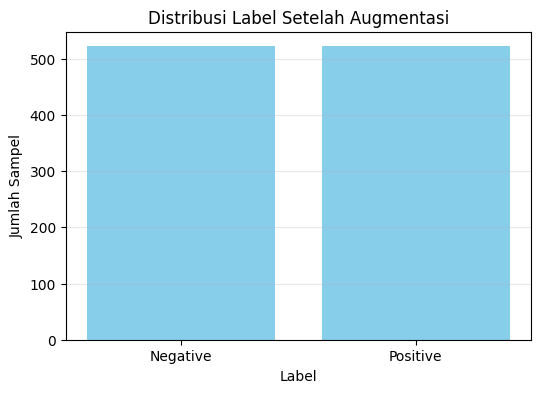

In [12]:
# ==========================================================
# 📦 ANALISIS JUMLAH DAN DISTRIBUSI DATASET SETELAH AUGMENTASI
# ==========================================================
import matplotlib.pyplot as plt
from collections import Counter

print("📊 Analisis data hasil augmentasi:")
total_before = len(X_train)
total_after  = len(X_train_final)
added = total_after - total_before

print(f"🧠 Total sebelum augmentasi: {total_before}")
print(f"🧩 Total sesudah augmentasi: {total_after}")
print(f"➕ Jumlah data tambahan hasil augmentasi: {added}")

# Distribusi label pada data training final
label_counts = Counter(y_train_final)
label_names = [inv_label[i] for i in sorted(label_counts.keys())]

print("\n📈 Distribusi label hasil augmentasi:")
for i, lbl in enumerate(label_names):
    print(f" - {lbl}: {label_counts[i]} sampel")

plt.figure(figsize=(6,4))
plt.bar(label_names, [label_counts[i] for i in sorted(label_counts.keys())], color='skyblue')
plt.title("Distribusi Label Setelah Augmentasi")
plt.xlabel("Label")
plt.ylabel("Jumlah Sampel")
plt.grid(axis='y', alpha=0.3)
plt.show()


In [13]:
# 1) Cek log augmentasi
!sed -n '1,200p' results/augmentation_log.txt

# ------------------------------------------------------
# 2.5) OPTIONAL: tampilkan info augmentasi
# ------------------------------------------------------
print("\n📘 augmentation_log.txt (preview):")
log_path = "results/augmentation_log.txt"
if os.path.exists(log_path):
    !sed -n '1,50p' results/augmentation_log.txt

print("\n📘 augmented_preview.csv (5 baris):")
prev_path = "results/augmented_preview.csv"
if os.path.exists(prev_path):
    display(pd.read_csv(prev_path).head())


# 3) Distribusi label setelah augmentasi
from collections import Counter
print("Distribusi label (train_final):", Counter(y_train_final))
print("Ukuran train_final:", len(X_train_final))


Total sebelum augment: 350
Total sesudah augment: 1044
Total augment ditambahkan: 695

📘 augmentation_log.txt (preview):
Total sebelum augment: 350
Total sesudah augment: 1044
Total augment ditambahkan: 695

📘 augmented_preview.csv (5 baris):


,text,label
0,gue ganti malah gue mau ngatasin jerawat di pi...,0
1,saya nggak merasakan bedanya sabun muka ini de...,1
2,kulit saya oilydehydrated plus sensitive. suuu...,1
3,cinta banget sama produk ini!!saya bisa pakai ...,1
4,"ini bagus bgt! meskkipun murah, tapi ini hasil...",1


Distribusi label (train_final): Counter({0: 522, 1: 522})
Ukuran train_final: 1044


In [14]:
# ==========================================================
# 4) ENCODING LABEL & CLASS WEIGHTS
# ==========================================================
# OneHotEncoder (kompatibel sklearn versi baru & lama)
try:
    ohe = OneHotEncoder(sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(sparse=False)

y_train_ohe = ohe.fit_transform(np.array(y_train_final).reshape(-1,1))
y_valid_ohe = ohe.transform(np.array(y_val).reshape(-1,1))
y_test_ohe  = ohe.transform(np.array(y_test).reshape(-1,1))

# class weights (untuk handle ketidakseimbangan jika ada; aman dipakai meski seimbang)
cw = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_final), y=np.array(y_train_final))
class_weight = {i: cw[i] for i in range(len(cw))}
print("⚖️ class_weight:", class_weight)


⚖️ class_weight: {0: 1.0, 1: 1.0}


# **TRAINING FUNCTION (Multi-variant IndoBERT)**

In [26]:
# ============================
# FINAL: SEL TRAINING YANG RAPI (OPTIMIZED VERSION)
# ============================

# --- imports & globals ---
import os, time, math, traceback, gc
import numpy as np
import pandas as pd
import tensorflow as tf

from transformers import AutoTokenizer, BertTokenizer, TFAutoModel
from huggingface_hub import snapshot_download

# Hyperparams
DEFAULT_EPOCHS = 12
DEFAULT_BATCH  = 16
INIT_LR = 2e-5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
MAX_LEN = 128

HF_TOKEN = os.environ.get("HF_TOKEN", None)
GELU_ACT = tf.nn.gelu


# ============================================================
# TOKENIZER LOADER (Robust)
# ============================================================
def load_indobert_tokenizer(model_name):
    try:
        return AutoTokenizer.from_pretrained(model_name, use_fast=True)
    except:
        pass
    try:
        return AutoTokenizer.from_pretrained(model_name, use_fast=False)
    except:
        pass
    try:
        return BertTokenizer.from_pretrained(model_name)
    except:
        pass
    try:
        if HF_TOKEN:
            local_dir = snapshot_download(repo_id=model_name, token=HF_TOKEN)
        else:
            local_dir = snapshot_download(repo_id=model_name)
        return AutoTokenizer.from_pretrained(local_dir, use_fast=False)
    except Exception as e:
        print("❌ FINAL tokenizer load failed:", e)
        return None


# ============================================================
# MODEL LIST
# ============================================================
model_ids = {
    "lite_base_p1":  "indobenchmark/indobert-lite-base-p1",
    "lite_base_p2":  "indobenchmark/indobert-lite-base-p2",
    "base_p1":       "indobenchmark/indobert-base-p1",
    "base_p2":       "indobenchmark/indobert-base-p2",
}


# ============================================================
# VALIDATE MODEL LIST
# ============================================================
valid_model_ids = {}
train_errors_log = "results/train_errors.log"
if os.path.exists(train_errors_log):
    os.remove(train_errors_log)

for key, model_name in model_ids.items():
    tok = load_indobert_tokenizer(model_name)
    if tok is None:
        print(f"⚠️ Skip {key}: tokenizer gagal → {model_name}")
        with open(train_errors_log, "a") as f:
            f.write(f"SKIP {key}: tokenizer fail\n")
    else:
        print(f"✅ Model valid: {key} → {model_name}")
        valid_model_ids[key] = model_name


# ============================================================
# SAFETY CHECK (DATASET)
# ============================================================
required = ["X_train_final","X_val","X_test",
            "y_train_ohe","y_valid_ohe","y_test_ohe",
            "class_names","class_weight"]

missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError("Variabel berikut belum tersedia: " + ", ".join(missing))


# ============================================================
# LR SCHEDULE — WarmUpThenDecay
# ============================================================
class WarmUpThenDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, init_lr, num_train_steps, warmup_steps, power=1.0):
        super().__init__()
        self.init_lr = init_lr
        self.num_train_steps = num_train_steps
        self.warmup_steps = warmup_steps
        self.decay_steps = max(1, num_train_steps - warmup_steps)
        self.power = power

        self.decay = tf.keras.optimizers.schedules.PolynomialDecay(
            initial_learning_rate=init_lr,
            decay_steps=self.decay_steps,
            end_learning_rate=0.0,
            power=self.power
        )

    def __call__(self, step):
        step_f = tf.cast(step, tf.float32)
        warm = float(self.warmup_steps)

        lr_warm = self.init_lr * (step_f / warm)
        decay_step = tf.maximum(0.0, step_f - warm)
        lr_decay = self.decay(tf.cast(decay_step, tf.int32))

        return tf.cond(
            step_f < warm,
            lambda: lr_warm,
            lambda: lr_decay
        )


class LrLogger(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate
        if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
            lr = lr(self.model.optimizer.iterations)
        print(f" - lr: {float(tf.keras.backend.get_value(lr)):.3e}")


# ============================================================
# OPTIMIZED TRAINING FUNCTION
# ============================================================
def train_indobert_variant(
        model_name, model_key,
        epochs=DEFAULT_EPOCHS,
        batch_size=DEFAULT_BATCH,
        init_lr=INIT_LR,
        warmup_ratio=WARMUP_RATIO,
        weight_decay=WEIGHT_DECAY,
        max_len=MAX_LEN):

    try:
        tf.keras.backend.clear_session()
        gc.collect()

        print(f"\n🚀 START OPTIMIZED TRAIN: {model_key} → {model_name}")

        os.makedirs("results", exist_ok=True)
        os.makedirs("ckpt", exist_ok=True)

        # -----------------------------
        # Tokenizer
        # -----------------------------
        tokenizer = load_indobert_tokenizer(model_name)
        if tokenizer is None:
            print("❌ Tokenizer gagal — SKIP model")
            return None

        train_enc = tokenizer(list(X_train_final), truncation=True, padding=True, max_length=max_len, return_tensors='tf')
        val_enc   = tokenizer(list(X_val),         truncation=True, padding=True, max_length=max_len, return_tensors='tf')
        test_enc  = tokenizer(list(X_test),        truncation=True, padding=True, max_length=max_len, return_tensors='tf')

        # -----------------------------
        # Load BERT Backbone
        # -----------------------------
        try:
            bert = TFAutoModel.from_pretrained(model_name, from_pt=True)
        except Exception as e:
            print("❌ Backbone gagal:", e)
            return None

        hidden_size = int(getattr(bert.config, "hidden_size", 768))

        # -----------------------------
        # Freeze 6 encoder layers (stabil)
        # -----------------------------
        print("🔒 Freezing encoder layers 0–5 ...")
        for layer in bert.layers[:6]:
            layer.trainable = False

        # -----------------------------
        # Architecture (HF TF FIX)
        # -----------------------------
        ids  = tf.keras.Input(shape=(max_len,), dtype=tf.int32, name="input_ids")
        mask = tf.keras.Input(shape=(max_len,), dtype=tf.int32, name="attention_mask")
        
        def bert_forward(inputs):
            input_ids, attention_mask = inputs
        
            outputs = bert(
                input_ids=input_ids,
                attention_mask=attention_mask,
                training=True
            )
        
            # CLS token from hidden state
            if hasattr(outputs, "last_hidden_state") and outputs.last_hidden_state is not None:
                return outputs.last_hidden_state[:, 0, :]
        
            # pooler output fallback
            if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
                return outputs.pooler_output
        
            # ultimate fallback
            return outputs[0][:, 0, :]
        
        rep = tf.keras.layers.Lambda(
            bert_forward,
            name="bert_representation",
            output_shape=(hidden_size,)   # <<<<<< FIX PENTING
        )([ids, mask])
        

        
        # -----------------------------
        # Classification Head
        # -----------------------------
        x = tf.keras.layers.Dense(256, activation="gelu")(rep)
        x = tf.keras.layers.Dropout(0.2)(x)
        x = tf.keras.layers.Dense(128, activation="gelu")(x)
        x = tf.keras.layers.Dropout(0.2)(x)
        
        out = tf.keras.layers.Dense(len(class_names), activation="softmax")(x)
        
        model = tf.keras.Model(inputs=[ids, mask], outputs=out)
        
                


        # -----------------------------
        # Optimizer + LR schedule
        # -----------------------------
        n_train = len(X_train_final)
        steps_per_epoch = math.ceil(n_train / batch_size)
        num_train_steps = steps_per_epoch * epochs
        warmup_steps = int(num_train_steps * warmup_ratio)

        lr_schedule = WarmUpThenDecay(init_lr, num_train_steps, warmup_steps)

        optimizer = tf.keras.optimizers.AdamW(
            learning_rate=lr_schedule,
            weight_decay=weight_decay
        )

        model.compile(
            optimizer=optimizer,
            loss="categorical_crossentropy",
            metrics=["categorical_accuracy"]
        )

        print(f"✅ Optimized model compiled | steps={num_train_steps}, warmup={warmup_steps}")

        # -----------------------------
        # Callbacks
        # -----------------------------
        ckpt_path = f"ckpt/ckpt_{model_key}.weights.h5"

        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True,
                verbose=1
            ),
            tf.keras.callbacks.ModelCheckpoint(
                filepath=ckpt_path,
                save_best_only=True,
                save_weights_only=True,
                monitor="val_loss",
                verbose=1
            ),
            LrLogger(),
        ]

        # -----------------------------
        # Training
        # -----------------------------
        history = model.fit(
            [train_enc["input_ids"], train_enc["attention_mask"]],
            y_train_ohe,
            validation_data=
                ([val_enc["input_ids"], val_enc["attention_mask"]], y_valid_ohe),
            batch_size=batch_size,
            epochs=epochs,
            class_weight=class_weight,
            callbacks=callbacks,
            verbose=1
        )

        # Save training history
        hist_path = f"results/history_{model_key}.csv"
        pd.DataFrame(history.history).to_csv(hist_path, index=False)
        print(f"💾 History saved → {hist_path}")

        # -----------------------------
        # Prediction (TEST)
        # -----------------------------
        y_prob = model.predict(
            [test_enc["input_ids"], test_enc["attention_mask"]],
            verbose=0
        )
        y_pred = np.argmax(y_prob, axis=1)
        y_true = np.argmax(y_test_ohe, axis=1)

        from sklearn.metrics import accuracy_score, classification_report
        acc = accuracy_score(y_true, y_pred)
        rep = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

        print(f"🎯 TEST ACC: {acc:.4f} | F1: {rep['weighted avg']['f1-score']:.4f}")

        # -----------------------------
        # Save Predictions
        # -----------------------------
        save_path = f"results/pred_{model_key}.csv"
        df_out = pd.DataFrame({
            "True": [class_names[i] for i in y_true],
            "Pred": [class_names[i] for i in y_pred],
        })

        for i, cname in enumerate(class_names):
            df_out[f"P({cname})"] = y_prob[:, i]

        df_out.to_csv(save_path, index=False)
        print(f"💾 Predictions saved → {save_path}")

        return {
            "accuracy": float(acc),
            "f1_score": float(rep["weighted avg"]["f1-score"]),
            "precision": float(rep["weighted avg"]["precision"]),
            "recall": float(rep["weighted avg"]["recall"])
        }

    except Exception as e:
        print("❌ ERROR TRAINING:", e)
        traceback.print_exc()
        return None


# ============================================================
# TRAIN LOOP
# ============================================================
results = {}
for key, model_name in valid_model_ids.items():
    print(f"\n--- TRAIN START [{key}] ---")
    res = train_indobert_variant(model_name, key)
    results[key] = res
    gc.collect()
    tf.keras.backend.clear_session()
    print(f"--- TRAIN DONE [{key}] ---")

# ============================================================
# SAVE MODEL COMPARISON
# ============================================================
results_filtered = {k:v for k,v in results.items() if v is not None}

if results_filtered:
    df_results = pd.DataFrame(results_filtered).T.sort_values("accuracy", ascending=False)
    df_results.to_csv("results/hasil_perbandingan_model.csv")
    display(df_results)
    print("📊 Hasil perbandingan model disimpan.")
else:
    print("⚠️ Tidak ada model berhasil dilatih.")


✅ Model valid: lite_base_p1 → indobenchmark/indobert-lite-base-p1
✅ Model valid: lite_base_p2 → indobenchmark/indobert-lite-base-p2
✅ Model valid: base_p1 → indobenchmark/indobert-base-p1
✅ Model valid: base_p2 → indobenchmark/indobert-base-p2

--- TRAIN START [lite_base_p1] ---

🚀 START OPTIMIZED TRAIN: lite_base_p1 → indobenchmark/indobert-lite-base-p1
🔒 Freezing encoder layers 0–5 ...
✅ Optimized model compiled | steps=792, warmup=79
Epoch 1/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - categorical_accuracy: 0.5376 - loss: 0.7063
Epoch 1: val_loss improved from inf to 0.62454, saving model to ckpt/ckpt_lite_base_p1.weights.h5
 - lr: 1.671e-05
66/66 ━━━━━━━━━━━━━━━━━━━━ 44s 339ms/step - categorical_accuracy: 0.5375 - loss: 0.7064 - val_categorical_accuracy: 0.7200 - val_loss: 0.6245
Epoch 2/12
65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - categorical_accuracy: 0.5584 - loss: 0.6832
Epoch 2: val_loss improved from 0.62454 to 0.58428, saving model to ckpt/ckpt_lite_base_p1.weights.h5
 - l

,accuracy,f1_score,precision,recall
lite_base_p1,0.80,0.799920,0.800481,0.80
base_p1,0.74,0.739896,0.740385,0.74
base_p2,0.74,0.739583,0.741546,0.74
lite_base_p2,0.70,0.696970,0.708333,0.70


📊 Hasil perbandingan model disimpan.


,accuracy,f1_score,precision,recall
lite_base_p1,0.80,0.799920,0.800481,0.80
base_p1,0.74,0.739896,0.740385,0.74
base_p2,0.74,0.739583,0.741546,0.74
lite_base_p2,0.70,0.696970,0.708333,0.70


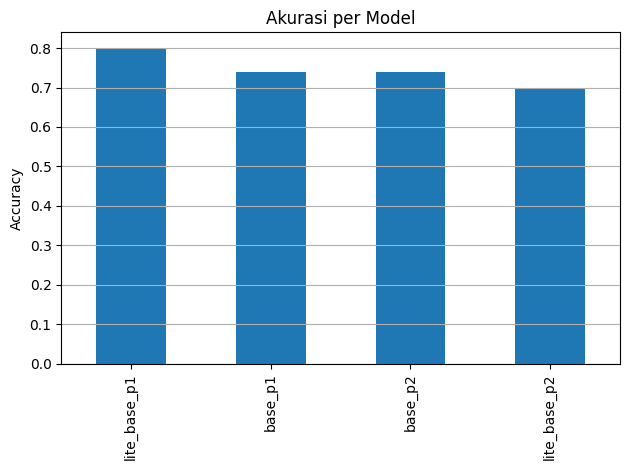

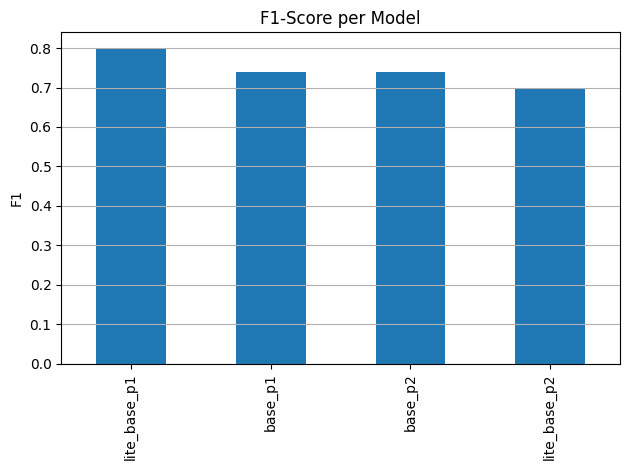

In [27]:
# =========================================================
# 9) Rekap & Visual
# =========================================================
results_filtered = {k: v for k, v in results.items() if v is not None}
df_results = pd.DataFrame(results_filtered).T.sort_values("accuracy", ascending=False)
df_results.to_csv("hasil_perbandingan_model.csv")
display(df_results)

plt.figure()
df_results["accuracy"].plot(kind="bar")
plt.title("Akurasi per Model"); plt.ylabel("Accuracy"); plt.grid(True, axis='y')
plt.tight_layout(); plt.savefig("compare_accuracy.png"); plt.show()

plt.figure()
df_results["f1_score"].plot(kind="bar")
plt.title("F1-Score per Model"); plt.ylabel("F1"); plt.grid(True, axis='y')
plt.tight_layout(); plt.savefig("compare_f1.png"); plt.show()

# **INFERENCE**

📊 Ringkasan hasil per model:


,accuracy,f1_score,precision,recall
lite_base_p1,0.77,0.769977,0.770108,0.77
lite_base_p2,0.77,0.768122,0.779041,0.77
base_p2,0.77,0.769977,0.770108,0.77
base_p1,0.76,0.760000,0.760000,0.76



🏆 Model terbaik (berdasarkan accuracy): lite_base_p1

🎯 METRIK TEST SET (model terbaik):
- Accuracy           : 0.7700
- Balanced Accuracy  : 0.7700
- Precision (weighted): 0.7701
- Recall (weighted)   : 0.7700
- F1-score (weighted) : 0.7700

📃 Classification report (per kelas):
              precision    recall  f1-score   support

    Negative       0.76      0.78      0.77        50
    Positive       0.78      0.76      0.77        50

    accuracy                           0.77       100
   macro avg       0.77      0.77      0.77       100
weighted avg       0.77      0.77      0.77       100



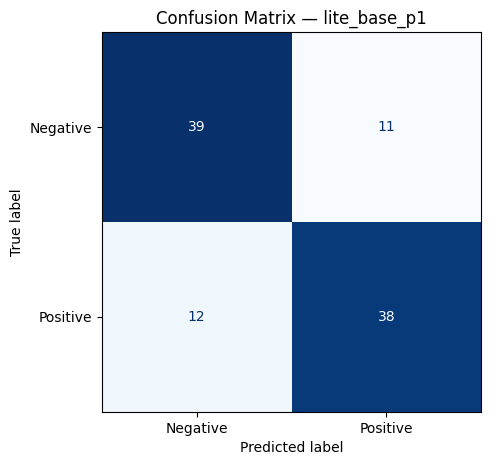


💡 Total kesalahan prediksi (misclassified) model lite_base_p1: 23

📊 Distribusi kesalahan berdasarkan label sebenarnya (True):
True
Positive    12
Negative    11
Name: count, dtype: int64
💾 Detail misclassified disimpan ke: results/misclassified_lite_base_p1.csv

📊 Ringkasan lengkap dengan Balanced Accuracy:


,accuracy,f1_score,precision,recall,balanced_accuracy,status
lite_base_p1,0.77,0.769977,0.770108,0.77,0.77,BEST
lite_base_p2,0.77,0.768122,0.779041,0.77,0.77,OTHER
base_p2,0.77,0.769977,0.770108,0.77,0.77,OTHER
base_p1,0.76,0.760000,0.760000,0.76,0.76,OTHER


💾 inference_metadata.json disimpan.
💾 Ringkasan semua model disimpan ke:
- results/summary_for_thesis.csv
- results/summary_for_thesis.json


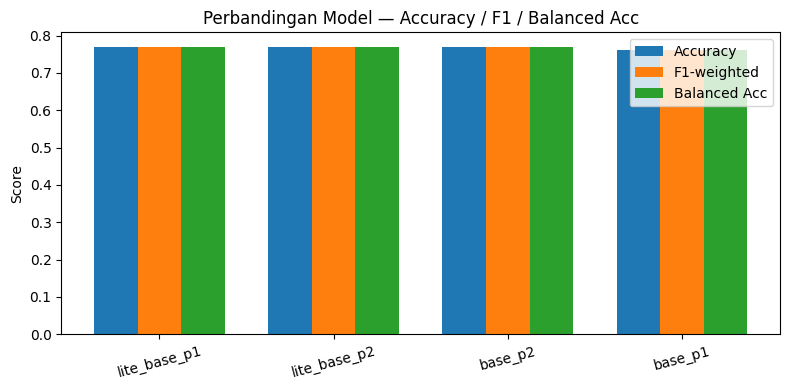

✅ Final comparison chart disimpan → results/final_comparison_chart.png


In [17]:
# ==========================================================
# 🔥 INFERENCE FINAL + EVALUASI + MISCLASSIFIED + EXPORT RINGKASAN
# ==========================================================
import os, json
import numpy as np
import pandas as p
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.preprocessing import LabelEncoder

# ----------------------------------------------------------
# 1) LOAD HASIL TRAINING (df_results)
# ----------------------------------------------------------
main_result_path = "results/hasil_perbandingan_model.csv"
if not os.path.exists(main_result_path):
    raise FileNotFoundError("⚠️ File results/hasil_perbandingan_model.csv tidak ditemukan. Jalankan training dulu.")

df_results = pd.read_csv(main_result_path, index_col=0)
if df_results.empty:
    raise RuntimeError("⚠️ df_results kosong. Periksa results/train_errors.log (mungkin semua model gagal).")

print("📊 Ringkasan hasil per model:")
display(df_results)

# ----------------------------------------------------------
# 2) TENTUKAN MODEL TERBAIK (berdasarkan accuracy tertinggi)
# ----------------------------------------------------------
# df_results sudah di-sort descending accuracy di bagian training
best_key = df_results.index[0]
print(f"\n🏆 Model terbaik (berdasarkan accuracy): {best_key}")

# prediksi hasil training sudah disimpan per model:
# results/pred_{model_key}.csv
pred_path_best = f"results/pred_{best_key}.csv"
if not os.path.exists(pred_path_best):
    raise FileNotFoundError(f"⚠️ File prediksi untuk model terbaik tidak ditemukan: {pred_path_best}")

df_pred_best = pd.read_csv(pred_path_best)

# ----------------------------------------------------------
# 3) REKONSTRUKSI LABEL & PROBABILITAS DARI FILE PREDIKSI
# ----------------------------------------------------------
if "True" not in df_pred_best.columns or "Pred" not in df_pred_best.columns:
    raise ValueError("⚠️ File prediksi tidak memiliki kolom 'True' dan 'Pred'.")

y_true_labels = df_pred_best["True"].astype(str).values
y_pred_labels = df_pred_best["Pred"].astype(str).values

# ambil kolom probabilitas: P(label)
prob_cols = [c for c in df_pred_best.columns if c.startswith("P(") and c.endswith(")")]
if prob_cols:
    y_prob = df_pred_best[prob_cols].values
    # class_names diambil dari nama kolom P(label)
    class_names = [c[2:-1] for c in prob_cols]
else:
    y_prob = None
    class_names = sorted(list(set(y_true_labels) | set(y_pred_labels)))

# encode label → integer untuk hitung metric
le = LabelEncoder()
le.fit(list(class_names))  # urutan kelas konsisten
y_true_idx = le.transform(y_true_labels)
y_pred_idx = le.transform(y_pred_labels)

# ----------------------------------------------------------
# 4) HITUNG METRIK AKHIR DI TEST SET UNTUK MODEL TERBAIK
# ----------------------------------------------------------
test_acc  = accuracy_score(y_true_idx, y_pred_idx)
test_bal  = balanced_accuracy_score(y_true_idx, y_pred_idx)
test_prec = precision_score(y_true_idx, y_pred_idx, average="weighted", zero_division=0)
test_rec  = recall_score(y_true_idx, y_pred_idx, average="weighted", zero_division=0)
test_f1   = f1_score(y_true_idx, y_pred_idx, average="weighted")

print("\n🎯 METRIK TEST SET (model terbaik):")
print(f"- Accuracy           : {test_acc:.4f}")
print(f"- Balanced Accuracy  : {test_bal:.4f}")
print(f"- Precision (weighted): {test_prec:.4f}")
print(f"- Recall (weighted)   : {test_rec:.4f}")
print(f"- F1-score (weighted) : {test_f1:.4f}")

print("\n📃 Classification report (per kelas):")
print(classification_report(y_true_idx, y_pred_idx, target_names=le.classes_))

# ----------------------------------------------------------
# 5) CONFUSION MATRIX (MODEL TERBAIK)
# ----------------------------------------------------------
cm = confusion_matrix(y_true_idx, y_pred_idx)
fig_cm, ax_cm = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax_cm, cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix — {best_key}")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 6) ANALISIS KESALAHAN (MISCLASSIFIED) UNTUK MODEL TERBAIK
# ----------------------------------------------------------
misclassified = df_pred_best.copy()
misclassified = misclassified[misclassified["True"] != misclassified["Pred"]].reset_index(drop=True)
total_mis = len(misclassified)

print(f"\n💡 Total kesalahan prediksi (misclassified) model {best_key}: {total_mis}")

# ringkasan kesalahan per kelas sebenarnya
if total_mis > 0:
    print("\n📊 Distribusi kesalahan berdasarkan label sebenarnya (True):")
    print(misclassified["True"].value_counts())

    # simpan detail kesalahan
    mis_detail_path = f"results/misclassified_{best_key}.csv"
    misclassified.to_csv(mis_detail_path, index=False, encoding="utf-8")
    print(f"💾 Detail misclassified disimpan ke: {mis_detail_path}")
else:
    print("🎉 Tidak ada kesalahan prediksi pada test set untuk model terbaik.")

# ringkasan singkat misclassification
mis_summary = {
    "best_model_key": best_key,
    "total_misclassified": int(total_mis),
    "total_samples": int(len(df_pred_best)),
}
with open("results/misclassified_summary.json", "w") as f:
    json.dump(mis_summary, f, indent=2, ensure_ascii=False)

# ----------------------------------------------------------
# 7) HITUNG BALANCED ACCURACY UNTUK SEMUA MODEL (BERDASARKAN FILE PRED_*.CSV)
# ----------------------------------------------------------
balanced_acc_all = {}

for key in df_results.index:
    pred_path = f"results/pred_{key}.csv"
    if not os.path.exists(pred_path):
        balanced_acc_all[key] = np.nan
        continue

    df_pred = pd.read_csv(pred_path)
    if "True" not in df_pred.columns or "Pred" not in df_pred.columns:
        balanced_acc_all[key] = np.nan
        continue

    y_true_l = df_pred["True"].astype(str).values
    y_pred_l = df_pred["Pred"].astype(str).values

    le_tmp = LabelEncoder()
    le_tmp.fit(list(set(y_true_l) | set(y_pred_l)))
    y_true_i = le_tmp.transform(y_true_l)
    y_pred_i = le_tmp.transform(y_pred_l)

    bal = balanced_accuracy_score(y_true_i, y_pred_i)
    balanced_acc_all[key] = bal

# tambahkan kolom Balanced Accuracy & Status (BEST / OTHERS)
df_summary = df_results.copy()
df_summary["balanced_accuracy"] = df_summary.index.map(balanced_acc_all)
df_summary["status"] = ["BEST" if idx == best_key else "OTHER" for idx in df_summary.index]

print("\n📊 Ringkasan lengkap dengan Balanced Accuracy:")
display(df_summary)

# ----------------------------------------------------------
# 8) SIMPAN METADATA INFERENCE & RINGKASAN UNTUK SKRIPSI
# ----------------------------------------------------------
# metadata untuk model terbaik
inference_metadata = {
    "best_model_key": best_key,
    "test_accuracy": float(test_acc),
    "test_balanced_accuracy": float(test_bal),
    "test_precision_weighted": float(test_prec),
    "test_recall_weighted": float(test_rec),
    "test_f1_weighted": float(test_f1),
    "total_misclassified": int(total_mis),
    "total_test_samples": int(len(df_pred_best)),
}
with open("results/inference_metadata.json", "w") as f:
    json.dump(inference_metadata, f, indent=2, ensure_ascii=False)
print("💾 inference_metadata.json disimpan.")

# ringkasan semua model (untuk tabel di skripsi)
summary_for_thesis_path_csv  = "results/summary_for_thesis.csv"
summary_for_thesis_path_json = "results/summary_for_thesis.json"
df_summary.to_csv(summary_for_thesis_path_csv, index=True, encoding="utf-8")
df_summary.to_json(summary_for_thesis_path_json, orient="index", force_ascii=False, indent=2)
print(f"💾 Ringkasan semua model disimpan ke:\n- {summary_for_thesis_path_csv}\n- {summary_for_thesis_path_json}")

# ----------------------------------------------------------
# 9) PLOT GABUNGAN: ACCURACY / F1 / BALANCED ACC UNTUK SEMUA MODEL
# ----------------------------------------------------------
plt.figure(figsize=(8,4))
ax = plt.gca()

bar_w = 0.25
x = np.arange(len(df_summary.index))

ax.bar(x - bar_w, df_summary["accuracy"].astype(float), width=bar_w, label="Accuracy")
ax.bar(x,         df_summary["f1_score"].astype(float), width=bar_w, label="F1-weighted")
ax.bar(x + bar_w, df_summary["balanced_accuracy"].astype(float), width=bar_w, label="Balanced Acc")

ax.set_xticks(x)
ax.set_xticklabels(df_summary.index, rotation=15)
ax.set_ylabel("Score")
ax.set_title("Perbandingan Model — Accuracy / F1 / Balanced Acc")
ax.legend()
plt.tight_layout()
plt.savefig("results/final_comparison_chart.png")
plt.show()

print("✅ Final comparison chart disimpan → results/final_comparison_chart.png")


# **ANALISIS AGREGAT: PER PRODUK, JENIS KULIT, DAN RATING**

Kolom df_pred_best: ['ID Data', 'Nama Produk', 'Jenis Kulit', 'Rating', 'Review Produk', 'True', 'Pred', 'P(Negative)', 'P(Positive)']


,ID Data,Nama Produk,Jenis Kulit,Rating,Review Produk,True,Pred,P(Negative),P(Positive)
0,A134,Hadalabo: Tamagohada Mild Peeling Face Wash,Combination,1,i wish i could love this...but :( padahal dike...,Negative,Negative,0.868395,0.131605
1,A034,Cetaphil: Gentle Skin Cleanser,Oily,1,waktu itu beli cetaphil yg gentle skin cleanse...,Negative,Negative,0.548203,0.451797
2,A254,Ponds: Acne Solution AntiAcne Facial Foam,Dry,5,pake pas ada bakal jerawat dan ampuh buat 'men...,Positive,Negative,0.665839,0.334161
3,A156,Cosrx: Low pH Good Morning Gel Cleanser,Dry,5,my holy graill !!! clenser yg selalu aku pakai...,Positive,Positive,0.075556,0.924444
4,A419,Wardah: Lightening Gentle Wash,Combination,1,saya pakai wardah lightening gentlewash dan ra...,Negative,Positive,0.497772,0.502228



📊 Sentimen per produk (urut dari positif tertinggi):


,n_review,pct_positive,mean_rating
Nama Produk,,,
Senka: Perfect Whip Facial Foam,4,1.000000,4.000000
SK-II: Facial Treatment Gentle Cleanser,4,0.750000,4.000000
The Body Shop: Tea Tree Skin Clearing Facial Wash,11,0.727273,3.181818
Laneige: Multi Cleanse EX,7,0.714286,4.428571
Wardah: Lightening Gentle Wash,10,0.500000,1.000000
Ponds: Acne Solution AntiAcne Facial Foam,16,0.437500,4.250000
Cetaphil: Gentle Skin Cleanser,5,0.400000,2.600000
Cosrx: Low pH Good Morning Gel Cleanser,8,0.375000,3.000000
Hadalabo: Gokujyun Ultimate Moisturizing Face Wash,8,0.375000,2.500000



📊 Sentimen per produk & jenis kulit (urut dari pct_positive terbesar):


,,n_review,pct_positive,mean_rating
Nama Produk,Jenis Kulit,,,
Cetaphil: Gentle Skin Cleanser,Normal,1,1.000000,5.000000
Senka: Perfect Whip Facial Foam,Combination,3,1.000000,3.666667
Laneige: Multi Cleanse EX,Oily,3,1.000000,5.000000
Hadalabo: Tamagohada Mild Peeling Face Wash,Normal,1,1.000000,5.000000
Laneige: Multi Cleanse EX,Dry,1,1.000000,5.000000
Hadalabo: Gokujyun Ultimate Moisturizing Face Wash,Normal,2,1.000000,5.000000
Cosrx: Low pH Good Morning Gel Cleanser,Dry,1,1.000000,5.000000
SK-II: Facial Treatment Gentle Cleanser,Normal,1,1.000000,5.000000
The Body Shop: Tea Tree Skin Clearing Facial Wash,Combination,4,1.000000,3.000000



📊 Distribusi sentimen berdasarkan rating (proporsi per rating):


Pred,Negative,Positive
Rating,,
1,0.78,0.22
5,0.24,0.76


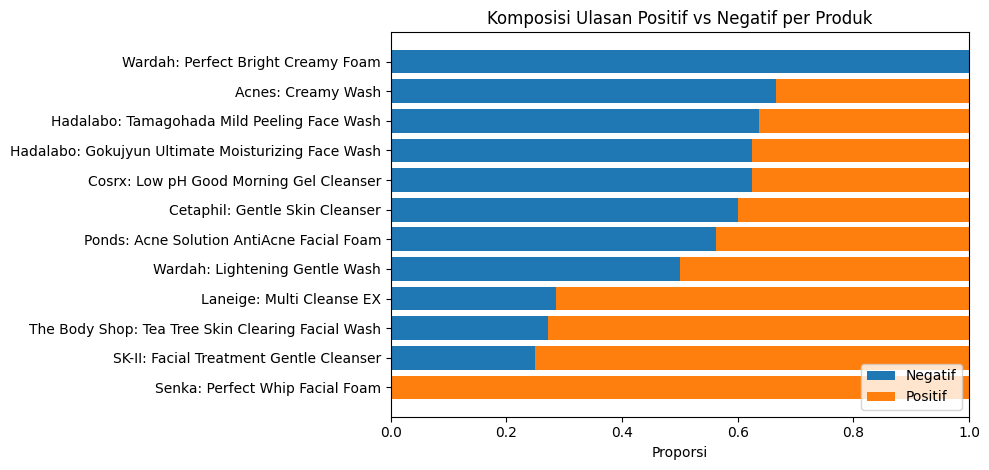

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


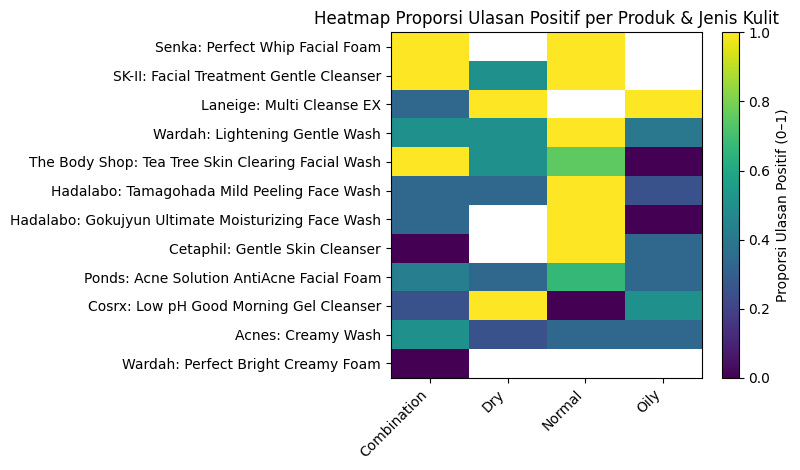

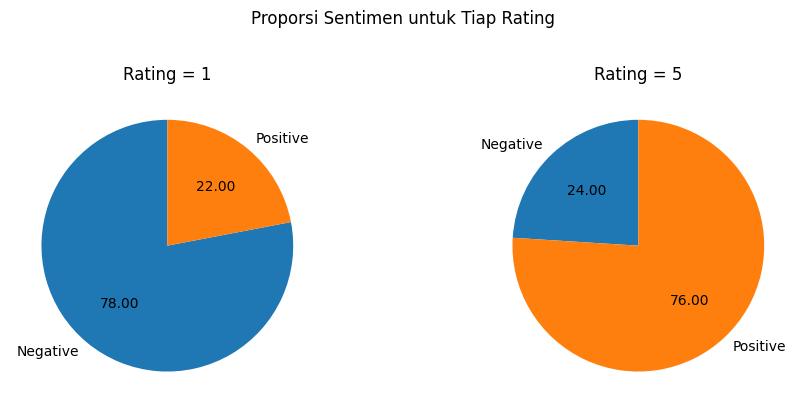

In [18]:
# ==========================================================
# 11) ANALISIS AGREGAT: PER PRODUK, JENIS KULIT, DAN RATING
# ==========================================================
import pandas as pd
import matplotlib.pyplot as plt

print("Kolom df_pred_best:", df_pred_best.columns.tolist())
display(df_pred_best.head())

# ----------------------------------------------------------
# 1) SENTIMEN PER PRODUK (SEMUA, URUT DARI POSITIF TERTINGGI)
# ----------------------------------------------------------
by_product = (
    df_pred_best
    .groupby("Nama Produk")
    .agg(
        n_review=("ID Data", "count"),
        pct_positive=("Pred", lambda x: (x == "Positive").mean()),
        mean_rating=("Rating", "mean")
    )
    .sort_values("pct_positive", ascending=False)
)

print("\n📊 Sentimen per produk (urut dari positif tertinggi):")
display(by_product)

# ----------------------------------------------------------
# 2) SENTIMEN PER PRODUK & JENIS KULIT (SEMUA, URUT pct_positive)
# ----------------------------------------------------------
by_prod_skin = (
    df_pred_best
    .groupby(["Nama Produk", "Jenis Kulit"])
    .agg(
        n_review=("ID Data", "count"),
        pct_positive=("Pred", lambda x: (x == "Positive").mean()),
        mean_rating=("Rating", "mean")
    )
    .sort_values("pct_positive", ascending=False)  # urut dari proporsi positif terbesar
)

print("\n📊 Sentimen per produk & jenis kulit (urut dari pct_positive terbesar):")
display(by_prod_skin)

# ----------------------------------------------------------
# 3) DISTRIBUSI SENTIMEN BERDASARKAN RATING
# ----------------------------------------------------------
crosstab_rating_sent = pd.crosstab(
    df_pred_best["Rating"],
    df_pred_best["Pred"],
    normalize="index"
)

print("\n📊 Distribusi sentimen berdasarkan rating (proporsi per rating):")
display(crosstab_rating_sent)

# ==========================================================
# 12) VISUALISASI: KURVA PERSENTASE POSITIF & PIE CHART SENTIMEN PER RATING
# ==========================================================

# ---------- 12.1 Stacked horizontal bar: proporsi positif & negatif per produk ----------
# hitung proporsi negatif
by_product_plot = by_product.copy()
by_product_plot["pct_negative"] = 1.0 - by_product_plot["pct_positive"]

# index produk & posisi Y
products = by_product_plot.index
y_pos = np.arange(len(products))

plt.figure(figsize=(10, max(4, 0.4 * len(products))))

plt.barh(y_pos,
         by_product_plot["pct_negative"],
         label="Negatif")
plt.barh(y_pos,
         by_product_plot["pct_positive"],
         left=by_product_plot["pct_negative"],
         label="Positif")

plt.yticks(y_pos, products)
plt.xlabel("Proporsi")
plt.title("Komposisi Ulasan Positif vs Negatif per Produk")
plt.legend(loc="lower right")
plt.xlim(0, 1)  # karena proporsi 0–1
plt.tight_layout()
plt.show()

# ---------- 12.2 Heatmap Produk × Jenis Kulit (pct_positive) ----------
# by_prod_skin sudah berisi:
# index: (Nama Produk, Jenis Kulit)
# kolom: n_review, pct_positive, mean_rating

# 1) Urutkan produk berdasarkan rata-rata pct_positive di semua jenis kulit
product_order = (
    by_prod_skin
    .groupby("Nama Produk")["pct_positive"]
    .mean()
    .sort_values(ascending=False)
    .index
)

# 2) Buat pivot: baris = Nama Produk, kolom = Jenis Kulit, nilai = pct_positive
pivot_skin = (
    by_prod_skin
    .reset_index()
    .pivot(index="Nama Produk", columns="Jenis Kulit", values="pct_positive")
    .loc[product_order]  # urutkan baris sesuai rata-rata tertinggi
)

plt.figure(figsize=(8, max(4, 0.4 * len(pivot_skin.index))))
im = plt.imshow(pivot_skin, aspect="auto")

cbar = plt.colorbar(im)
cbar.set_label("Proporsi Ulasan Positif (0–1)")

plt.xticks(range(len(pivot_skin.columns)), pivot_skin.columns, rotation=45, ha="right")
plt.yticks(range(len(pivot_skin.index)), pivot_skin.index)
plt.title("Heatmap Proporsi Ulasan Positif per Produk & Jenis Kulit")
plt.tight_layout()
plt.show()



# ---------- 12.2 Pie chart proporsi sentimen per rating ----------
n_ratings = len(crosstab_rating_sent.index)
fig, axes = plt.subplots(1, n_ratings, figsize=(5 * n_ratings, 4))

if n_ratings == 1:
    axes = [axes]  # supaya bisa di-iterasi

for ax, rating in zip(axes, crosstab_rating_sent.index):
    values = crosstab_rating_sent.loc[rating].values
    labels = crosstab_rating_sent.columns

    ax.pie(
        values,
        labels=labels,
        autopct="%1.2f",  # tampilkan proporsi (2 desimal)
        startangle=90
    )
    ax.set_title(f"Rating = {rating}")

plt.suptitle("Proporsi Sentimen untuk Tiap Rating", y=1.02)
plt.tight_layout()
plt.show()

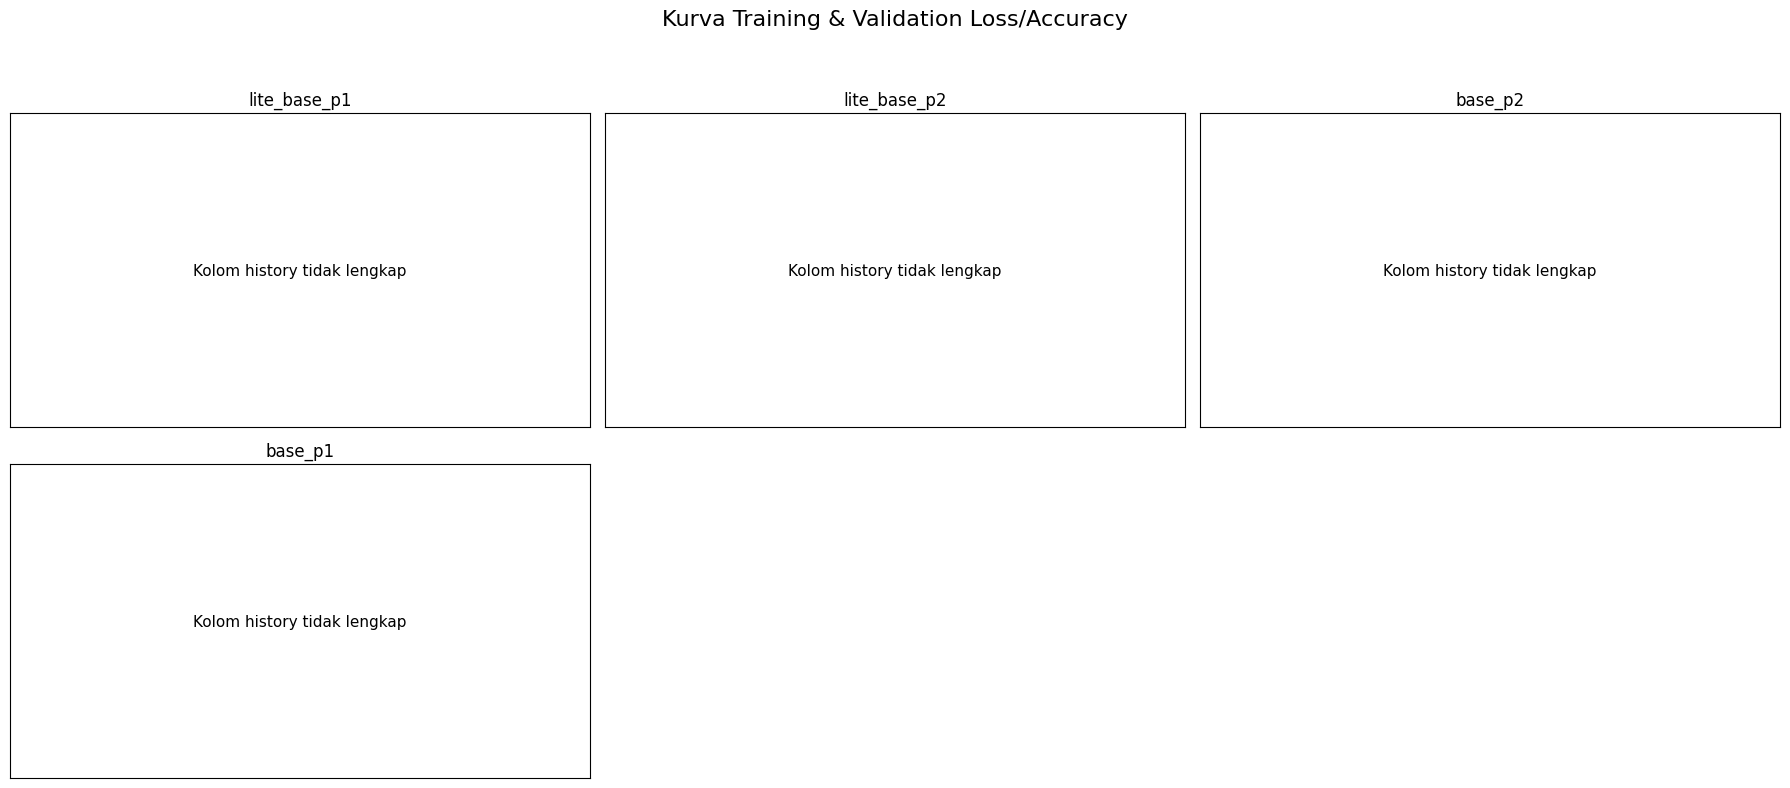

In [19]:
# ==========================================================
# 10) KURVA TRAINING vs VALIDATION (LOSS & ACCURACY) SEMUA MODEL
# ==========================================================
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pakai df_summary dari cell evaluasi sebelumnya
# Jika belum ada, fallback ke hasil perbandingan model
if "df_summary" not in globals():
    df_summary = pd.read_csv("results/hasil_perbandingan_model.csv", index_col=0)

all_model_keys = list(df_summary.index)

# --- cek model yang benar-benar punya history_*.csv ---
history_infos = []   # (model_key, history_df)
for key in all_model_keys:
    history_path = f"results/history_{key}.csv"
    if not os.path.exists(history_path):
        print(f"⚠️ History file tidak ditemukan untuk model {key}: {history_path}")
        continue

    hist = pd.read_csv(history_path)
    history_infos.append((key, hist))

n_models = len(history_infos)

if n_models == 0:
    print("⚠️ Tidak ada file history_*.csv yang ditemukan di folder results/.")
    print("   Jalankan ulang training setelah menambahkan kode penyimpanan history.")
else:
    # --- siapkan layout subplot ---
    # maksimum 3 kolom per baris
    n_cols = min(3, n_models)
    n_rows = math.ceil(n_models / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))

    # pastikan axes bisa di-iterasi satu dimensi
    if isinstance(axes, np.ndarray):
        axes = axes.ravel()
    else:
        axes = np.array([axes])

    fig.suptitle("Kurva Training & Validation Loss/Accuracy", fontsize=16)

    # --- plotting per model ---
    for i, (key, hist) in enumerate(history_infos):
        ax = axes[i]

        acc_col_candidates      = [c for c in hist.columns if c.lower() in ("accuracy", "acc", "train_accuracy")]
        val_acc_col_candidates  = [c for c in hist.columns if "val_" in c.lower() and "acc" in c.lower()]
        loss_col_candidates     = [c for c in hist.columns if c.lower() == "loss"]
        val_loss_col_candidates = [c for c in hist.columns if "val_" in c.lower() and "loss" in c.lower()]

        if not acc_col_candidates or not val_acc_col_candidates or not loss_col_candidates or not val_loss_col_candidates:
            ax.text(0.5, 0.5, "Kolom history tidak lengkap",
                    ha="center", va="center", fontsize=11)
            ax.set_title(key)
            ax.set_xticks([])
            ax.set_yticks([])
            continue

        acc_col      = acc_col_candidates[0]
        val_acc_col  = val_acc_col_candidates[0]
        loss_col     = loss_col_candidates[0]
        val_loss_col = val_loss_col_candidates[0]

        if "epoch" in hist.columns:
            epochs = hist["epoch"]
        else:
            epochs = np.arange(1, len(hist) + 1)

        ax.plot(epochs, hist[acc_col],      label="train acc")
        ax.plot(epochs, hist[val_acc_col],  label="val acc")
        ax.plot(epochs, hist[loss_col],     label="train loss")
        ax.plot(epochs, hist[val_loss_col], label="val loss")

        ax.set_title(key)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Score / Loss")
        ax.legend()
        ax.grid(True)

    # sembunyikan axes yang tidak terpakai
    for j in range(n_models, len(axes)):
        axes[j].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


In [20]:
import os

print("Isi root:")
print(os.listdir("."))

print("\nAda folder results_no_aug? ", os.path.exists("results_no_aug"))
if os.path.exists("results_no_aug"):
    print("Isi results_no_aug:")
    print(os.listdir("results_no_aug"))

print("\nIsi folder results (utama):")
print(os.listdir("results"))


Isi root:
['hasil_perbandingan_model.csv', 'results', 'ckpt', 'compare_f1.png', 'compare_accuracy.png', 'models', '.virtual_documents']

Ada folder results_no_aug?  False

Isi folder results (utama):
['hasil_perbandingan_model.csv', 'misclassified_lite_base_p1.csv', 'pred_base_p2.csv', 'misclassified_summary.json', 'pred_lite_base_p2.csv', 'history_lite_base_p2.csv', 'augmentation_log.txt', 'summary_for_thesis.json', 'pred_lite_base_p1.csv', 'augmented_preview.csv', 'history_lite_base_p1.csv', 'history_base_p1.csv', 'history_base_p2.csv', 'inference_metadata.json', 'final_comparison_chart.png', 'pred_base_p1.csv', 'summary_for_thesis.csv']


In [21]:
import os
print(os.listdir("."))


['hasil_perbandingan_model.csv', 'results', 'ckpt', 'compare_f1.png', 'compare_accuracy.png', 'models', '.virtual_documents']
